# Hill climbing

Hill climbing blends models greedily. I start from the best single model, then add models one at a time with a weight, keeping any addition that improves the blended CV score. It stops when nothing helps.

The metric is AUC, higher is better, but hill_climb_ensemble minimizes its metric. So I pass 1 minus AUC. Minimizing AUC-error is the same as maximizing AUC.

In [1]:
VER = 1

## Load data

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

train = pd.read_parquet('data/train_features.parquet')
y_train_true = train['PitNextLap'].astype(int).values
print('Train shape:', train.shape)

Train shape: (439140, 114)


## Model scores

The current models and their OOF AUC. Four baselines from 03, two stacking models from 04.

In [3]:
model_names = ['linear', 'xgb', 'lgb', 'cb', 'stack_target', 'stack_feature']
oof_list, test_list = [], []
for k in model_names:
    oof_list.append(np.load(f'data/train_oof_{k}_v{VER}.npy'))
    test_list.append(np.load(f'data/test_pred_{k}_v{VER}.npy').mean(0))

aucs = [roc_auc_score(y_train_true, oof) for oof in oof_list]
for m, a in zip(model_names, aucs):
    print(f'{m:14s} model has {a:.5f} OOF AUC')

linear         model has 0.87888 OOF AUC
xgb            model has 0.92424 OOF AUC
lgb            model has 0.93033 OOF AUC
cb             model has 0.93186 OOF AUC
stack_target   model has 0.92602 OOF AUC
stack_feature  model has 0.90991 OOF AUC


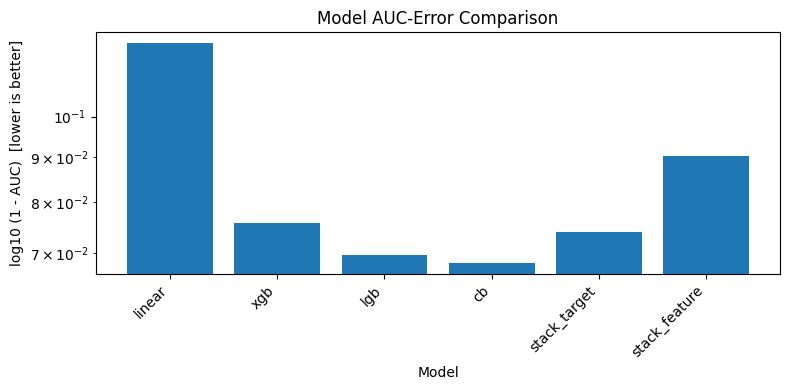

In [4]:
# Plot AUC-error (1 - AUC) on a log scale: lower is better, like the RMSE chart in the template.
errs = [1 - a for a in aucs]
plt.figure(figsize=(8, 4))
plt.bar(model_names, errs)
plt.ylabel('log10 (1 - AUC)  [lower is better]')
plt.xlabel('Model')
plt.title('Model AUC-Error Comparison')
plt.xticks(rotation=45, ha='right')
plt.yscale('log')
plt.tight_layout()
plt.show()

## Hill climbing

I run hill climbing over the six models. It starts from the most accurate one, then blends in the others one at a time to push CV AUC up.

In [5]:
from data.utils import hill_climb_ensemble

def neg_auc(y_true, y_pred):
    # hill_climb_ensemble minimizes its metric; minimizing (1 - AUC) maximizes AUC.
    return 1.0 - roc_auc_score(y_true, y_pred)

result = hill_climb_ensemble(
    oofs=oof_list,
    test_preds=test_list,
    names=model_names,
    y_true=y_train_true,
    metric=neg_auc,
    max_number_models=None,
    tolerance=1e-6,
    use_negative_weights=False,
)

Initial model: cb  score=0.068142


Add model: lgb  alpha=0.3600  score=0.067441


Add model: stack_feature  alpha=0.0100  score=0.067427


Stopping: improvement 0.000e+00 < tolerance

Final ensemble (collapsed):
                    cb  weight=0.633600
                   lgb  weight=0.356400
         stack_feature  weight=0.010000


Final score = 0.067427


In [6]:
oof_auc = roc_auc_score(y_train_true, result['oof_pred'])
print(f'Hill-Climb Ensemble, CV OOF AUC: {oof_auc:.5f}')
print('weights:', dict(zip(result['used_names'], np.round(result['weights'], 4))))

Hill-Climb Ensemble, CV OOF AUC: 0.93257
weights: {'cb': np.float64(0.6336), 'lgb': np.float64(0.3564), 'stack_feature': np.float64(0.01)}


## Ensemble result

The hill-climb ensemble should sit below every single model on AUC-error.

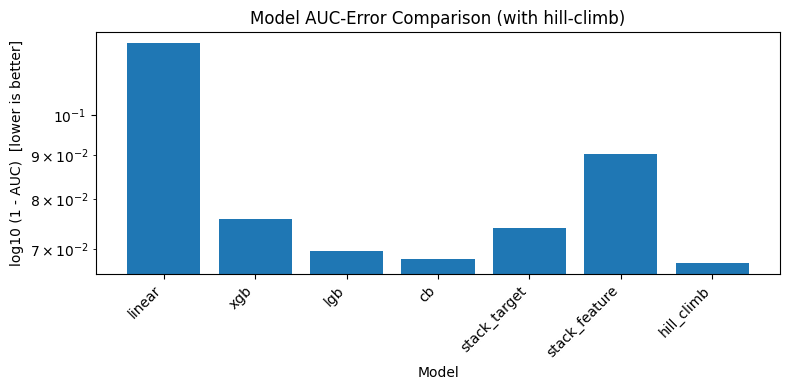

In [7]:
model_names2 = model_names + ['hill_climb']
errs2 = [1 - a for a in aucs] + [1 - oof_auc]
plt.figure(figsize=(8, 4))
plt.bar(model_names2, errs2)
plt.ylabel('log10 (1 - AUC)  [lower is better]')
plt.xlabel('Model')
plt.title('Model AUC-Error Comparison (with hill-climb)')
plt.xticks(rotation=45, ha='right')
plt.yscale('log')
plt.tight_layout()
plt.show()

In [8]:
# Save the hill-climb ensemble OOF/PRED for the downstream notebooks.
np.save(f'data/train_oof_hill_climb_v{VER}.npy', result['oof_pred'])
np.save(f'data/test_pred_hill_climb_v{VER}.npy', result['test_pred'][None, :])